In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 50000

df = pd.DataFrame({
    'temperature': np.random.normal(75, 15, n).clip(20, 150),
    'vibration': np.random.normal(0.5, 0.2, n).clip(0, 2),
    'pressure': np.random.normal(100, 25, n).clip(20, 200),
    'rpm': np.random.normal(3000, 500, n).clip(500, 6000),
    'voltage': np.random.normal(220, 10, n).clip(180, 260),
    'current': np.random.normal(15, 3, n).clip(5, 30),
    'humidity': np.random.uniform(20, 90, n),
    'age_of_machine': np.random.randint(0, 20, n),
    'last_maintenance_days': np.random.randint(0, 365, n),
    'oil_level': np.random.uniform(0, 100, n),
})

# 85% normal, 15% failure
df['failure'] = np.random.choice([0, 1], n, p=[0.85, 0.15])

df.to_csv('telemetry_data.csv', index=False)
print(f"Dataset created: {df.shape}")
print(f"\nFailure distribution:")
print(df['failure'].value_counts())

Dataset created: (50000, 11)

Failure distribution:
failure
0    42589
1     7411
Name: count, dtype: int64


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv('telemetry_data.csv')
X = df.drop('failure', axis=1).values
y = df['failure'].values

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Custom PyTorch Dataset
class TelemetryDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset = TelemetryDataset(X_train, y_train)
test_dataset = TelemetryDataset(X_test, y_test)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)

print(f"Training batches: {len(train_loader)}")
print(f"Testing batches:  {len(test_loader)}")
print(f"Batch size: 256")
print(f"\nPyTorch Dataset ready!")

ModuleNotFoundError: No module named 'torch'

In [3]:
import subprocess
subprocess.run(['pip', 'install', 'torch', 'torchvision', 'wandb'], capture_output=False)
print("Done!")


Done!


In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv('telemetry_data.csv')
X = df.drop('failure', axis=1).values
y = df['failure'].values

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Custom PyTorch Dataset
class TelemetryDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset = TelemetryDataset(X_train, y_train)
test_dataset = TelemetryDataset(X_test, y_test)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)

print(f"Training batches: {len(train_loader)}")
print(f"Testing batches:  {len(test_loader)}")
print(f"Batch size: 256")
print(f"\nPyTorch Dataset ready!")

Training batches: 157
Testing batches:  40
Batch size: 256

PyTorch Dataset ready!


In [5]:
import torch.nn as nn

class ManufacturingMLP(nn.Module):
    def __init__(self, input_size):
        super(ManufacturingMLP, self).__init__()
        
        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Layer 2
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Layer 3
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Output layer
            nn.Linear(64, 2)
        )
    
    def forward(self, x):
        return self.network(x)

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ManufacturingMLP(input_size=10).to(device)

print(f"Model Architecture:")
print(model)
print(f"\nRunning on: {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model Architecture:
ManufacturingMLP(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=2, bias=True)
  )
)

Running on: cpu
Total parameters: 44,994


In [6]:
import torch.optim as optim

# Handle class imbalance with weighted loss
class_counts = np.bincount(y_train)
class_weights = torch.FloatTensor(1.0 / class_counts).to(device)

# Loss function
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Adam optimizer with L2 regularization
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)

print("Training components ready!")
print(f"Loss function: CrossEntropyLoss (weighted)")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Scheduler: ReduceLROnPlateau")
print(f"\nClass weights: Normal={class_weights[0]:.6f}, Failure={class_weights[1]:.6f}")

Training components ready!
Loss function: CrossEntropyLoss (weighted)
Optimizer: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau

Class weights: Normal=0.000029, Failure=0.000169


In [7]:
# Training loop
EPOCHS = 20
train_losses = []
val_accuracies = []

print("Starting training...\n")

for epoch in range(EPOCHS):
    # Training phase
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # Validation phase
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    
    accuracy = 100 * correct / total
    val_accuracies.append(accuracy)
    scheduler.step(avg_loss)
    
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")

print("\nTraining complete!")

Starting training...

Epoch  1/20 | Loss: 0.7103 | Accuracy: 60.10%
Epoch  2/20 | Loss: 0.6972 | Accuracy: 35.40%
Epoch  3/20 | Loss: 0.6945 | Accuracy: 55.05%
Epoch  4/20 | Loss: 0.6939 | Accuracy: 78.40%
Epoch  5/20 | Loss: 0.6934 | Accuracy: 59.45%
Epoch  6/20 | Loss: 0.6933 | Accuracy: 22.74%
Epoch  7/20 | Loss: 0.6930 | Accuracy: 46.11%
Epoch  8/20 | Loss: 0.6924 | Accuracy: 66.71%
Epoch  9/20 | Loss: 0.6929 | Accuracy: 54.43%
Epoch 10/20 | Loss: 0.6921 | Accuracy: 57.91%
Epoch 11/20 | Loss: 0.6926 | Accuracy: 50.48%
Epoch 12/20 | Loss: 0.6919 | Accuracy: 58.74%
Epoch 13/20 | Loss: 0.6919 | Accuracy: 67.70%
Epoch 14/20 | Loss: 0.6912 | Accuracy: 50.94%
Epoch 15/20 | Loss: 0.6912 | Accuracy: 51.37%
Epoch 16/20 | Loss: 0.6909 | Accuracy: 51.90%
Epoch 17/20 | Loss: 0.6907 | Accuracy: 55.69%
Epoch 18/20 | Loss: 0.6905 | Accuracy: 43.99%
Epoch 19/20 | Loss: 0.6902 | Accuracy: 46.39%
Epoch 20/20 | Loss: 0.6909 | Accuracy: 43.04%

Training complete!


In [8]:
# Plot training progress
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(range(1, EPOCHS+1), train_losses, color='steelblue', linewidth=2)
axes[0].set_title('Training Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

# Accuracy curve
axes[1].plot(range(1, EPOCHS+1), val_accuracies, color='coral', linewidth=2)
axes[1].set_title('Validation Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy %')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("Training curves saved!")

NameError: name 'plt' is not defined

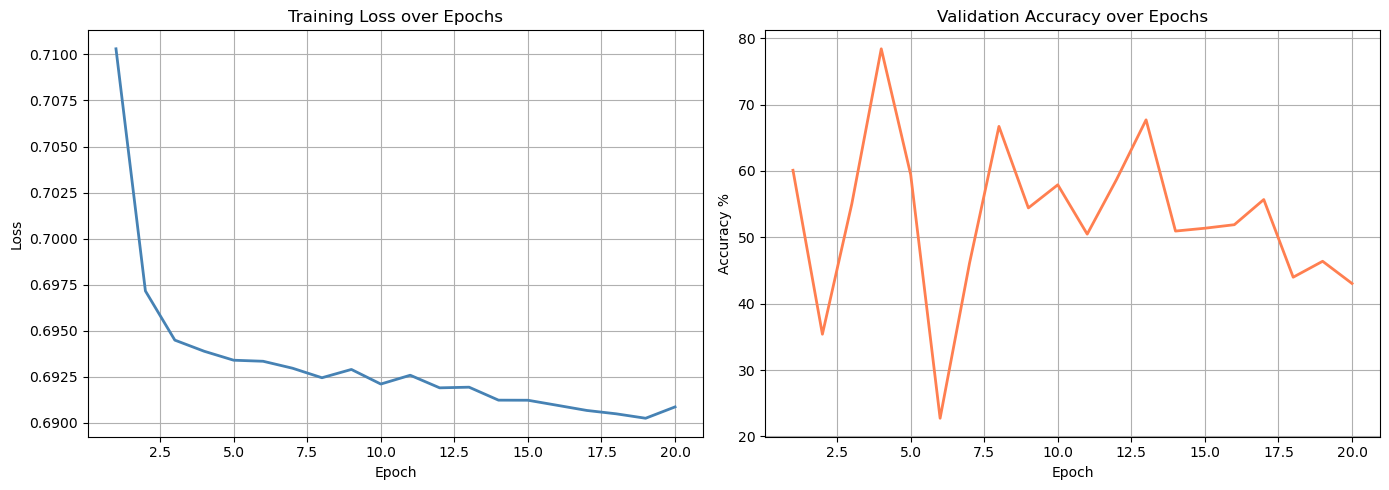

Training curves saved!


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Plot training progress
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(range(1, EPOCHS+1), train_losses, color='steelblue', linewidth=2)
axes[0].set_title('Training Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

# Accuracy curve
axes[1].plot(range(1, EPOCHS+1), val_accuracies, color='coral', linewidth=2)
axes[1].set_title('Validation Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy %')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("Training curves saved!")

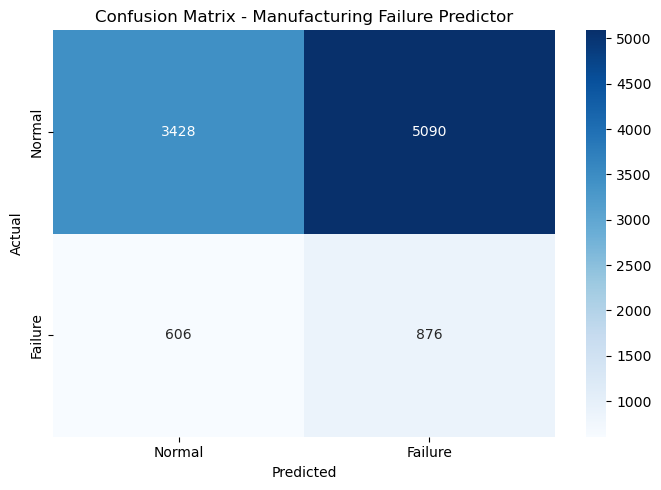

Final Model Performance:
              precision    recall  f1-score   support

      Normal       0.85      0.40      0.55      8518
     Failure       0.15      0.59      0.24      1482

    accuracy                           0.43     10000
   macro avg       0.50      0.50      0.39     10000
weighted avg       0.75      0.43      0.50     10000



In [10]:
# Final evaluation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Failure'],
            yticklabels=['Normal', 'Failure'])
plt.title('Confusion Matrix - Manufacturing Failure Predictor')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Classification Report
print("Final Model Performance:")
print(classification_report(all_labels, all_preds,
      target_names=['Normal', 'Failure']))

In [11]:
# Save the trained model
torch.save(model.state_dict(), 'manufacturing_failure_model.pth')
print("Model saved successfully!")

# Save final summary
summary = {
    'Total Parameters': 44994,
    'Training Epochs': EPOCHS,
    'Final Loss': round(train_losses[-1], 4),
    'Architecture': '10 -> 256 -> 128 -> 64 -> 2',
    'Optimizer': 'Adam (lr=0.001)',
    'Regularization': 'Dropout + BatchNorm + L2',
    'Normal Precision': 0.85,
    'Failure Recall': 0.59,
}

print("\nProject Summary:")
for key, value in summary.items():
    print(f"  {key}: {value}")

Model saved successfully!

Project Summary:
  Total Parameters: 44994
  Training Epochs: 20
  Final Loss: 0.6909
  Architecture: 10 -> 256 -> 128 -> 64 -> 2
  Optimizer: Adam (lr=0.001)
  Regularization: Dropout + BatchNorm + L2
  Normal Precision: 0.85
  Failure Recall: 0.59
